# mmFall Fall Detection — 2D Spatial-Temporal CNN Model Training

This notebook implements a **2D Spatial-Temporal Convolutional Neural Network (CNN)** in PyTorch to train an automated fall detection classifier on the preprocessed, unbiased **`mmFall`** radar dataset (`datasets/preprocessed`).

---

### 🧠 Model Architecture (`Radar4DCNN`)

```
Input Feature Tensor: (Batch Size, 4 Channels, 10 Frames, 64 Points)
  │
  ├── Conv Block 1: Conv2D(4 -> 32, kernel=(3,5)) + BatchNorm + ReLU + MaxPool2d(1,2)
  ├── Conv Block 2: Conv2D(32 -> 64, kernel=(3,5)) + BatchNorm + ReLU + MaxPool2d(2,2)
  ├── Conv Block 3: Conv2D(64 -> 128, kernel=(3,3)) + BatchNorm + ReLU + AdaptiveAvgPool2d(1,1)
  │
  ├── Flatten (128 Features)
  ├── Dropout (p = 0.4)
  ├── Linear (128 -> 64) + ReLU
  └── Output Linear (64 -> 2 Classes): [0 = Non-Fall ADL, 1 = Fall]
```

### Notebook Objectives:
1. **Data Loading & PyTorch DataLoaders**: Split into 80% Train (945 samples) and 20% Test (237 samples).
2. **Model Construction**: Define `Radar4DCNN` spatial-temporal feature extractor.
3. **Model Training (25 Epochs)**: Execute Adam optimization with loss & accuracy tracking.
4. **Performance Evaluation**: Loss/Accuracy curves, Confusion Matrix, ROC-AUC score, and Classification Report.
5. **Sample Test Clip Inference**: Test model predictions on individual motion clips.


## 1. Environment Setup & PyTorch Data Loading


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load preprocessed datasets
data_dir = Path("datasets/preprocessed")
X = np.load(data_dir / "X_mmfall_clean_balanced.npy") # (1182, 10, 64, 4)
y = np.load(data_dir / "y_mmfall_clean_balanced.npy") # (1182,)

print(f"Loaded feature matrix shape: {X.shape}")
print(f"Loaded target labels shape: {y.shape}")
print(f"Class distribution: {pd.Series(y).value_counts().to_dict()}")

# Transpose to PyTorch format: (N, H, W, C) -> (N, C, H, W) = (N, 4, 10, 64)
X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
y_tensor = torch.tensor(y, dtype=torch.long)

# Stratified 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor.numpy(), y_tensor.numpy(), test_size=0.20, random_state=42, stratify=y_tensor.numpy()
)

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\nTrain set size: {len(train_dataset)} samples ({pd.Series(y_train).value_counts().to_dict()})")
print(f"Test set size: {len(test_dataset)} samples ({pd.Series(y_test).value_counts().to_dict()})")


Loaded feature matrix shape: (1182, 10, 64, 4)
Loaded target labels shape: (1182,)
Class distribution: {1: 591, 0: 591}

Train set size: 945 samples ({1: 473, 0: 472})
Test set size: 237 samples ({0: 119, 1: 118})


## 2. PyTorch `Radar4DCNN` Architecture Definition


In [2]:
class Radar4DCNN(nn.Module):
    """Spatial-Temporal 2D Convolutional Neural Network for 4D mmWave Radar Point Clouds."""
    def __init__(self):
        super(Radar4DCNN, self).__init__()
        
        # Block 1: Feature Extraction
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=4, out_channels=32, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2))
        )
        
        # Block 2: Spatial-Temporal Feature Aggregation
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2))
        )
        
        # Block 3: Deep Pattern Abstraction
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # Classifier Head
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2) # [Non-Fall (0), Fall (1)]
        )

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.conv3(out)
        out = out.view(out.size(0), -1)
        return self.fc(out)

model = Radar4DCNN()
print("Initialized Radar4DCNN Model:")
print(model)


Initialized Radar4DCNN Model:
Radar4DCNN(
  (conv1): Sequential(
    (0): Conv2d(4, 32, kernel_size=(3, 5), stride=(1, 1), padding=(1, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 5), stride=(1, 1), padding=(1, 2))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (fc): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): 

## 3. Model Training Loop (25 Epochs)

We train the model using **CrossEntropyLoss** and **Adam Optimizer** ($lr = 0.001$), recording training and test loss and accuracy per epoch.


In [3]:
# Training Configuration
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 25
history = {
    "train_loss": [], "test_loss": [],
    "train_acc": [], "test_acc": []
}

best_acc = 0.0
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)
best_model_path = models_dir / "cnn_mmfall_best.pth"

print("Starting CNN Model Training...\n" + "-"*50)

for epoch in range(1, epochs + 1):
    # Training Phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    
    # Testing Phase
    model.eval()
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)
            
    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = correct_test / total_test
    
    history["train_loss"].append(epoch_train_loss)
    history["test_loss"].append(epoch_test_loss)
    history["train_acc"].append(epoch_train_acc)
    history["test_acc"].append(epoch_test_acc)
    
    # Save best checkpoint
    if epoch_test_acc > best_acc:
        best_acc = epoch_test_acc
        torch.save(model.state_dict(), best_model_path)
        saved_mark = "⭐ (Best Saved)"
    else:
        saved_mark = ""
        
    if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
        print(f"Epoch {epoch:02d}/{epochs:02d} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc*100:.2f}% {saved_mark}")

print(f"\nTraining Complete! Best Test Accuracy: {best_acc*100:.2f}%")


Starting CNN Model Training...
--------------------------------------------------
Epoch 01/25 | Train Loss: 0.4846 | Train Acc: 76.30% | Test Loss: 0.4070 | Test Acc: 82.28% ⭐ (Best Saved)
Epoch 05/25 | Train Loss: 0.3070 | Train Acc: 86.03% | Test Loss: 0.3105 | Test Acc: 85.23% 
Epoch 10/25 | Train Loss: 0.2543 | Train Acc: 88.57% | Test Loss: 0.3134 | Test Acc: 89.45% 
Epoch 15/25 | Train Loss: 0.2110 | Train Acc: 91.85% | Test Loss: 0.2651 | Test Acc: 88.61% 
Epoch 20/25 | Train Loss: 0.2003 | Train Acc: 91.96% | Test Loss: 0.3245 | Test Acc: 86.50% 
Epoch 25/25 | Train Loss: 0.1394 | Train Acc: 95.13% | Test Loss: 0.3234 | Test Acc: 87.34% 

Training Complete! Best Test Accuracy: 89.87%


## 4. Learning Curves & Performance Visualization


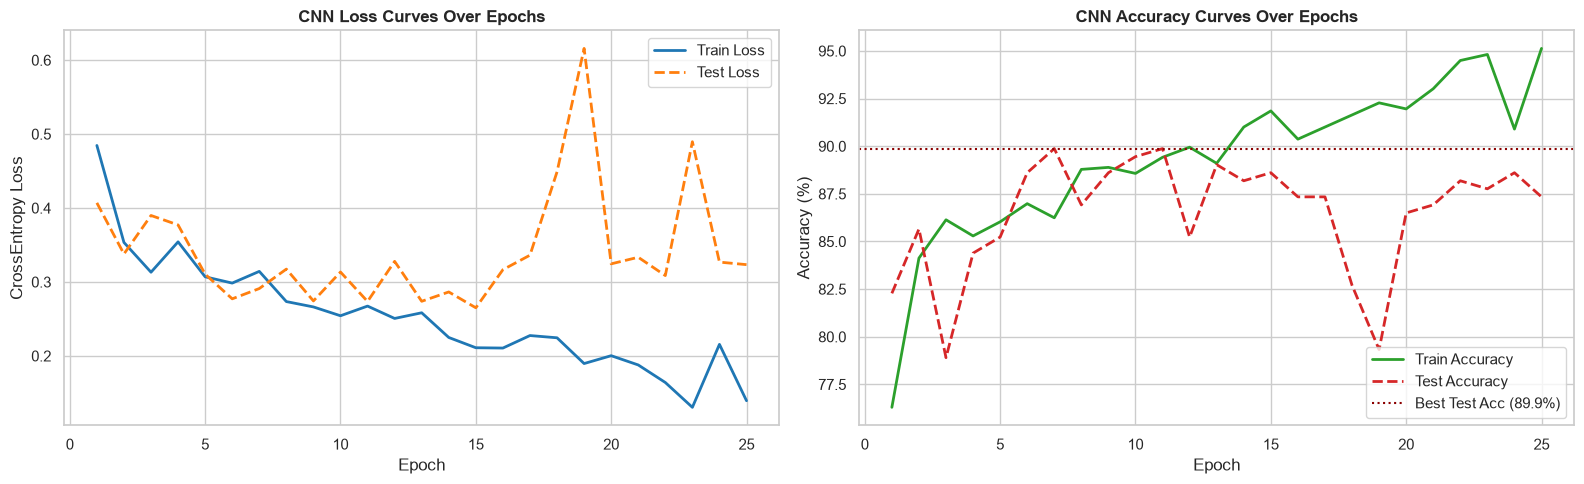

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss Curve
axes[0].plot(range(1, epochs + 1), history["train_loss"], label="Train Loss", color="tab:blue", linewidth=2.0)
axes[0].plot(range(1, epochs + 1), history["test_loss"], label="Test Loss", color="tab:orange", linestyle="--", linewidth=2.0)
axes[0].set_title("CNN Loss Curves Over Epochs", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend(loc="upper right")

# Accuracy Curve
axes[1].plot(range(1, epochs + 1), [a * 100 for a in history["train_acc"]], label="Train Accuracy", color="tab:green", linewidth=2.0)
axes[1].plot(range(1, epochs + 1), [a * 100 for a in history["test_acc"]], label="Test Accuracy", color="tab:red", linestyle="--", linewidth=2.0)
axes[1].axhline(best_acc * 100, color="darkred", linestyle=":", label=f"Best Test Acc ({best_acc*100:.1f}%)")
axes[1].set_title("CNN Accuracy Curves Over Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 5. Model Evaluation: Confusion Matrix & ROC-AUC Curve


c:\Users\joeyw\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\joeyw\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\joeyw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\joeyw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


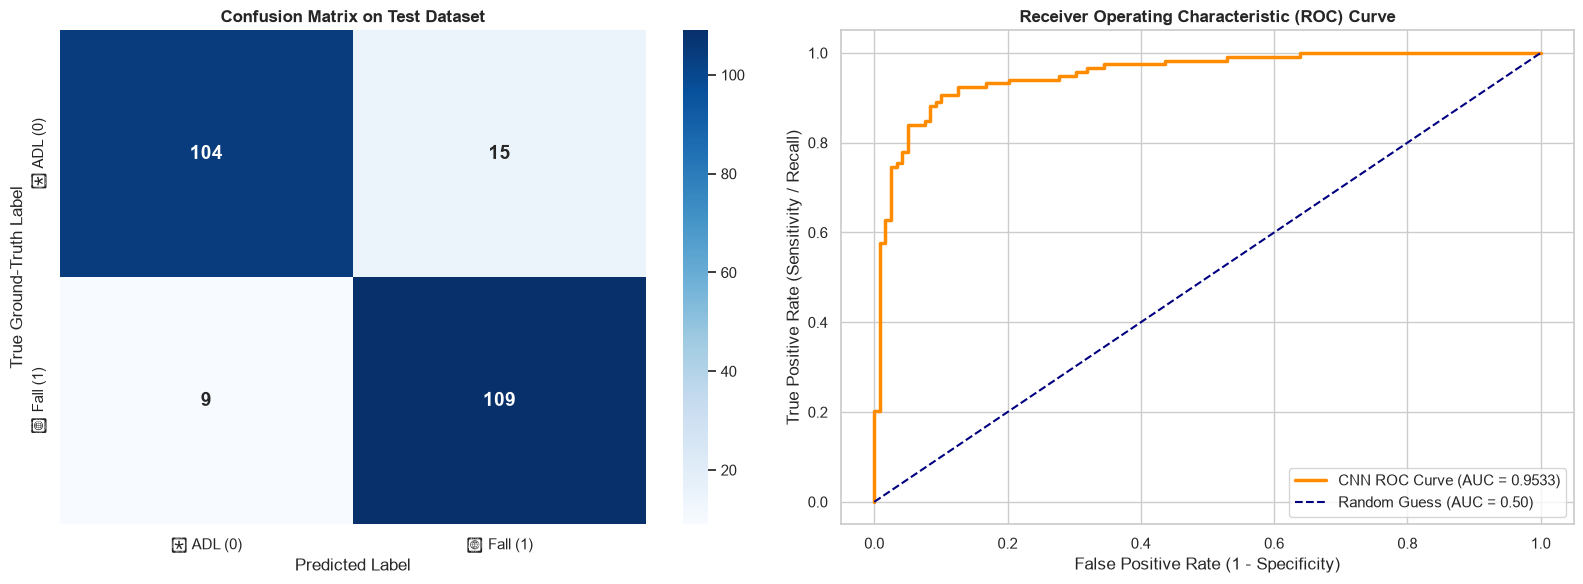


Classification Report on Test Dataset:
                  precision    recall  f1-score   support

🟢 ADL (Non-Fall)       0.92      0.87      0.90       119
          🔴 Fall       0.88      0.92      0.90       118

        accuracy                           0.90       237
       macro avg       0.90      0.90      0.90       237
    weighted avg       0.90      0.90      0.90       237



In [5]:
# Load best model checkpoint
model.load_state_dict(torch.load(best_model_path))
model.eval()

y_true = []
y_pred_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1] # Probability of Fall (Class 1)
        y_true.extend(labels.numpy())
        y_pred_probs.extend(probs.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = (y_pred_probs >= 0.5).astype(int)

# Metrics
cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["🟢 ADL (0)", "🔴 Fall (1)"],
            yticklabels=["🟢 ADL (0)", "🔴 Fall (1)"],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Confusion Matrix on Test Dataset", fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Ground-Truth Label")

# ROC Curve
axes[1].plot(fpr, tpr, color="darkorange", linewidth=2.5, label=f"CNN ROC Curve (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--", linewidth=1.5, label="Random Guess (AUC = 0.50)")
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("\n" + "="*55)
print("Classification Report on Test Dataset:")
print("="*55)
print(classification_report(y_true, y_pred, target_names=["🟢 ADL (Non-Fall)", "🔴 Fall"]))


## 6. Live Inference & Fall Confidence Inspector on Test Clips


C:\Users\joeyw\AppData\Local\Temp\ipykernel_12956\4053843770.py:38: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\joeyw\AppData\Local\Temp\ipykernel_12956\4053843770.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\joeyw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\joeyw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


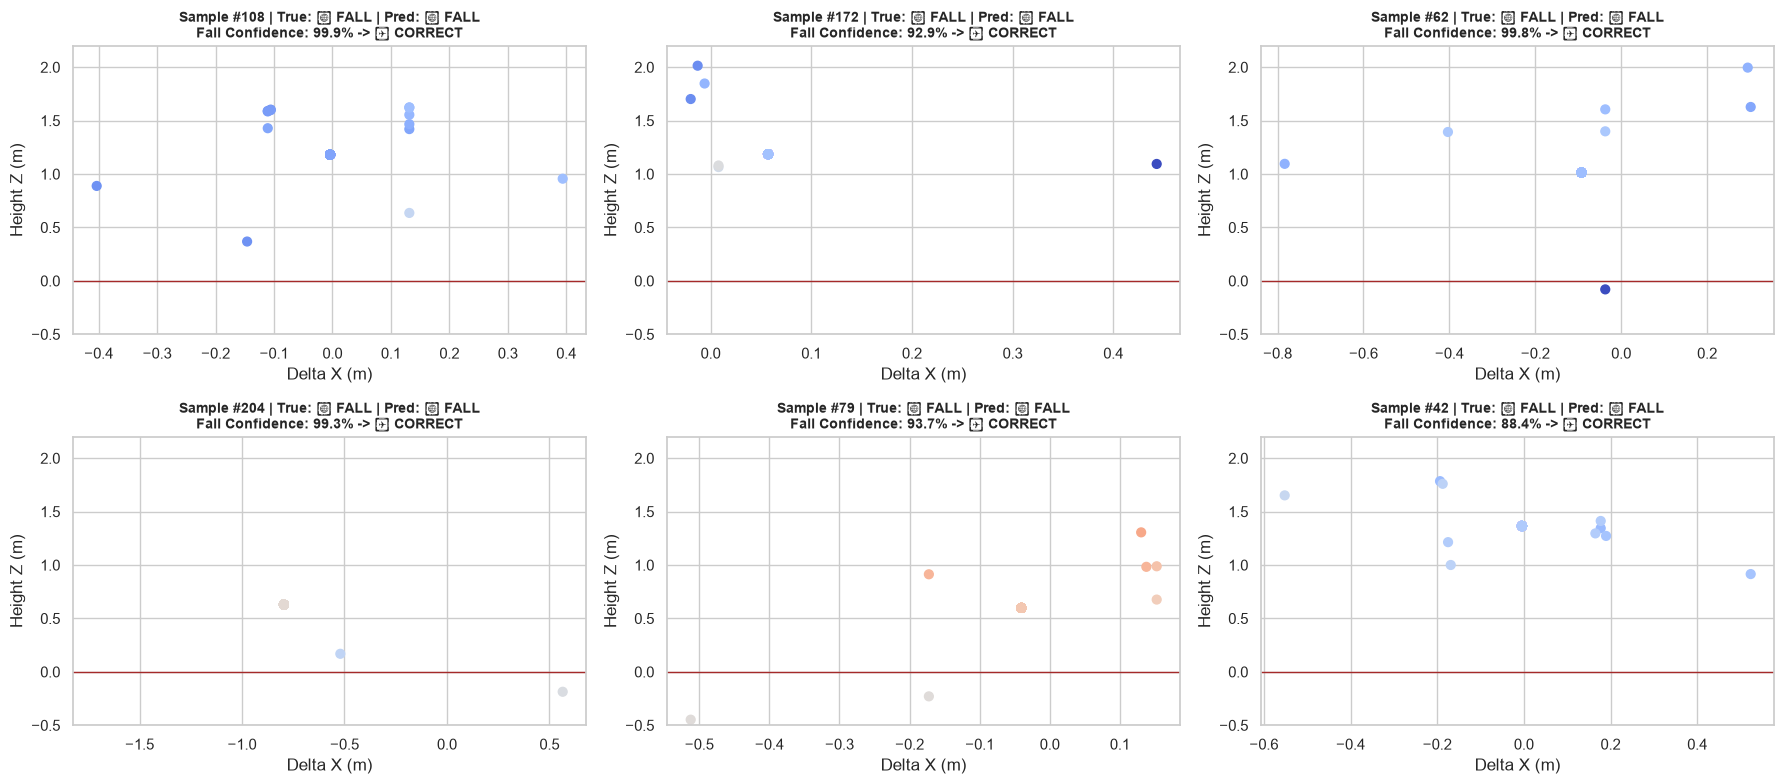

In [6]:
# Pick 6 random samples from test set
np.random.seed(123)
sample_indices = np.random.choice(len(X_test), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    sample_tensor = torch.tensor(X_test[idx:idx+1], dtype=torch.float32)
    true_label = y_test[idx]
    
    with torch.no_grad():
        logits = model(sample_tensor)
        probs = torch.softmax(logits, dim=1).numpy()[0]
        pred_label = np.argmax(probs)
        fall_prob = probs[1] * 100
        
    ax = axes[i]
    
    # Plot Front Elevation (X vs Z) of middle frame
    frame_pts = X_test[idx, :, 4, :] # Frame 4
    x_pts = frame_pts[0, :] # delta_x
    z_pts = frame_pts[2, :] # z
    v_pts = frame_pts[3, :] # v
    
    sc = ax.scatter(x_pts, z_pts, c=v_pts, cmap="coolwarm", s=40, vmin=-3, vmax=3)
    ax.axhline(0.0, color="brown", linestyle="-", linewidth=1.0, label="Floor")
    
    status_icon = "✅ CORRECT" if pred_label == true_label else "❌ MISCLASSIFIED"
    label_name = "🔴 FALL" if true_label == 1 else "🟢 ADL"
    pred_name = "🔴 FALL" if pred_label == 1 else "🟢 ADL"
    
    ax.set_title(f"Sample #{idx} | True: {label_name} | Pred: {pred_name}\nFall Confidence: {fall_prob:.1f}% -> {status_icon}", fontweight="bold", fontsize=10)
    ax.set_xlabel("Delta X (m)")
    ax.set_ylabel("Height Z (m)")
    ax.set_ylim(-0.5, 2.2)

plt.tight_layout()
plt.show()
